# Example 3 - When the data is OOM

In [1]:
import rapidsegment as rs
from prettytable import PrettyTable
import pandas as pd
from rapidsegment import UniversalDataLoader
from rapidsegment import StrategicSegmentBuilder
from rapidsegment import StrategicSegmentScore
import duckdb
import pyarrow as pa
import os
import matplotlib.pyplot as plt
pd.options.display.max_columns = 100

In [2]:
print(f"RapidSegment version: {rs.__version__}")

RapidSegment version: 1.3.3


# LOAD DATA

In [3]:
data_path = r"D:\RapidSegment\RapidSegment\Notebooks\Term_Deposit_Sub\bank_train.csv"
table_name = 'bank_train'
data = UniversalDataLoader(file_path=data_path).stream_to_duckdb(table_name=table_name)


2026-09-20 21:43:26,962 | INFO     | [data_loader.py:371] | 🗄️ No db_path given — created default database at: C:\Users\BISHWA~1\AppData\Local\Temp\rapidsegment_udl_6955dc82.duckdb


In [4]:
con = duckdb.connect(data)
print(con.sql(f"SELECT * FROM {table_name} LIMIT 10"))

┌────────┬──────────────┬──────────┬───────────┬─────────┬─────────┬─────────┬─────────┬───────────┬────────┬─────────┬──────────┬──────────┬────────┬──────────┬──────────┬─────────┐
│  age   │     job      │ marital  │ education │ default │ balance │ housing │  loan   │  contact  │  day   │  month  │ duration │ campaign │ pdays  │ previous │ poutcome │    y    │
│ double │   varchar    │ varchar  │  varchar  │ boolean │ double  │ boolean │ boolean │  varchar  │ double │ varchar │  double  │  double  │ double │  double  │ varchar  │ boolean │
├────────┼──────────────┼──────────┼───────────┼─────────┼─────────┼─────────┼─────────┼───────────┼────────┼─────────┼──────────┼──────────┼────────┼──────────┼──────────┼─────────┤
│   46.0 │ blue-collar  │ married  │ primary   │ false   │  -339.0 │ true    │ true    │ cellular  │   11.0 │ may     │    182.0 │      2.0 │   -1.0 │      0.0 │ unknown  │ false   │
│   38.0 │ management   │ married  │ tertiary  │ false   │     0.0 │ true    │ false 

#### Notes
- Here income is the target variable. But we see that it is not one hot encoded or not binary in nature.
- We need to binarize the variable before we proceed to segment creation

# Binarizing Target Variable
    Using duckdb SQL native syntax to perform the binarization

In [5]:
# define the sql query
# this converts 'active' status to 1, and all other statuses to 0
target_col = "y"
sql_query = f"""
CREATE OR REPLACE TABLE {table_name} AS (
SELECT
    *,
   CAST({target_col} AS DOUBLE) AS {target_col}_binary,
    CAST("default" as DOUBLE) AS default_binary,
    CAST("loan" as DOUBLE) AS loan_binary,
    CAST("housing" as DOUBLE) AS housing_binary ,
FROM
    {table_name})
"""

# execute the query and fetch the result directly as a pyarrow table
con.execute(sql_query)
print(con.sql(f"SELECT * FROM {table_name} LIMIT 10"))
con.close()

┌────────┬──────────────┬──────────┬───────────┬─────────┬─────────┬─────────┬─────────┬───────────┬────────┬─────────┬──────────┬──────────┬────────┬──────────┬──────────┬─────────┬──────────┬────────────────┬─────────────┬────────────────┐
│  age   │     job      │ marital  │ education │ default │ balance │ housing │  loan   │  contact  │  day   │  month  │ duration │ campaign │ pdays  │ previous │ poutcome │    y    │ y_binary │ default_binary │ loan_binary │ housing_binary │
│ double │   varchar    │ varchar  │  varchar  │ boolean │ double  │ boolean │ boolean │  varchar  │ double │ varchar │  double  │  double  │ double │  double  │ varchar  │ boolean │  double  │     double     │   double    │     double     │
├────────┼──────────────┼──────────┼───────────┼─────────┼─────────┼─────────┼─────────┼───────────┼────────┼─────────┼──────────┼──────────┼────────┼──────────┼──────────┼─────────┼──────────┼────────────────┼─────────────┼────────────────┤
│   46.0 │ blue-collar  │ marrie

# Setup Experiment

Naive path


In [6]:
param_grid = {'min_sample_size': [20000, 15000, 10000, 5000, 500],'min_lift': [3.0, 2.0, 1.5]}
builder = StrategicSegmentBuilder(target = target_col+'_binary',
                                  min_sample_size = 100,
                                  min_lift = 1.0, 
                                  min_events  = 50, 
                                  top_n_vars = 10,
                                  max_segments = 10,
                                  param_grid = param_grid,
                                  enable_diversity = False, 
                                  max_feature_reuse = 5, 
                                  enable_1way = True,
                                  enable_2way = True,
                                  enable_3way = True,
                                  feature_groups = None,
                                  ignore_features = [target_col,"loan","default",'housing'],
                                  sort_priority = 'lift_rate_count',
                                  binning_method="optimal_cart",
                                  selection_metric='iv',
                                  db_path = None)

#### Rule Mining

In [7]:
segments_df = builder.extract_segments(data)

2026-09-20 21:43:27,716 | INFO     | [builder.py:1299] | 🚀 Starting hierarchical segment extraction...
2026-09-20 21:43:27,718 | INFO     | [builder.py:1324] | 📂 Created temporary disk-backed DB at: C:\Users\BISHWA~1\AppData\Local\Temp\rapidsegment_9ae7835c\segmentation_20260920_025869df.duckdb
2026-09-20 21:43:27,746 | INFO     | [builder.py:303] | ⚙️ DuckDB Configured: Threads=14/16, MemoryLimit=11GB, TempDir=C:\Users\BISHWA~1\AppData\Local\Temp\rapidsegment_9ae7835c\tmp_20260920_025869df
2026-09-20 21:43:27,747 | INFO     | [builder.py:1328] | 📊 Sort priority: lift_rate_count
2026-09-20 21:43:27,748 | INFO     | [builder.py:1329] | 📦 Binning method: optimal_cart
2026-09-20 21:43:27,865 | INFO     | [builder.py:1412] | 📊 Dynamic Grid Search Enabled: 15 configurations.
2026-09-20 21:43:27,868 | INFO     | [builder.py:1420] | 🔒 Locking Original Base Rate: 11.70%
2026-09-20 21:43:27,871 | INFO     | [builder.py:1446] | 🔄 Iteration 1 | Remaining Volume: 40,689 | Base Rate: 11.70%
2026-09

### Segment Evaluation

In [8]:
final_eval = builder.evaluate_final_coverage(data)

2026-09-20 21:43:42,865 | INFO     | [builder.py:1868] | 📊 Evaluating final hierarchical coverage on original data...
2026-09-20 21:43:42,886 | INFO     | [builder.py:303] | ⚙️ DuckDB Configured: Threads=14/16, MemoryLimit=11GB, TempDir=<none>


# Final Segment Report

In [9]:

table = PrettyTable()
table.field_names = list(pd.DataFrame(final_eval).columns)
for _, row in pd.DataFrame(final_eval).iterrows():
    table.add_row(list(row))
print(table)

+---------+-------------+---------------+--------------------+--------------------+--------------------+--------------------+---------------------------+--------------------------+
| segment | total_count | target_events |   response_rate    | base_response_rate |    capture_rate    |        lift        | cumulative_sample_capture | cumulative_event_capture |
+---------+-------------+---------------+--------------------+--------------------+--------------------+--------------------+---------------------------+--------------------------+
|   1.0   |    506.0    |     317.0     | 62.648221343873516 | 11.698493450318267 | 1.2435793457691269 | 5.3552383997077095 |     1.2435793457691269    |    6.659663865546219     |
|   2.0   |    739.0    |     442.0     | 59.810554803788904 | 11.698493450318267 | 1.8162156848288236 | 5.1126715638894265 |      3.05979503059795     |    15.945378151260504    |
|   3.0   |    650.0    |     368.0     | 56.61538461538461  | 11.698493450318267 | 1.597483349

# Segment SQL definition

In [10]:
print("--- FULL SEGMENT RULES ---\n")

for index, row in pd.DataFrame(segments_df).iterrows():
    print(f"Segment ID: {row['segment_id']}")
    print(f"Raw Rule:   {row['rule_string']}")
    print(f"SQL Filter: {row['sql_filter']}")
    print("-" * 50)

--- FULL SEGMENT RULES ---

Segment ID: 1
Raw Rule:   housing_binary=(-inf, 0.50) & month=[apr, oct, dec, sep, mar] & poutcome=[other, success]
SQL Filter: ("housing_binary" < 0.50) AND ("month" IN ('apr', 'oct', 'dec', 'sep', 'mar')) AND ("poutcome" IN ('other', 'success'))
--------------------------------------------------
Segment ID: 2
Raw Rule:   contact=[cellular] & duration=[702.50, inf) & housing_binary=(-inf, 0.50)
SQL Filter: ("contact" IN ('cellular')) AND ("duration" >= 702.50) AND ("housing_binary" < 0.50)
--------------------------------------------------
Segment ID: 3
Raw Rule:   housing_binary=(-inf, 0.50) & pdays=[9.50, 187.50) & poutcome=[other, success]
SQL Filter: ("housing_binary" < 0.50) AND ("pdays" >= 9.50 AND "pdays" < 187.50) AND ("poutcome" IN ('other', 'success'))
--------------------------------------------------
Segment ID: 4
Raw Rule:   contact=[cellular] & duration=[647.50, inf) & previous=(-inf, 0.50)
SQL Filter: ("contact" IN ('cellular')) AND ("duratio

##### Segment Meta informations
-  We can see the raw string and the parsed sql here in the below table.
- We can also see what hyper parameters were satisfied to mine the segment

In [11]:

table = PrettyTable()
table.field_names = list(pd.DataFrame(segments_df).columns)
for _, row in pd.DataFrame(segments_df).iterrows():
    table.add_row(list(row))
print(table)

+------------+-------------------------------------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------+-------+--------------------+--------------------+--------------------------+-----------------------+
| segment_id |                                        rule_string                                        |                                                        sql_filter                                                       | count |        rate        |        lift        | meta_applied_sample_size | meta_applied_min_lift |
+------------+-------------------------------------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------+-------+--------------------+--------------------+--------------------------+-----------------------+
|     1   

# Diagnostics

- Check why no futher segments were generated

In [12]:
print(builder.explain_no_segments())

SEGMENT EXTRACTION DIAGNOSTIC REPORT
Segments Extracted : 10 / 10
Iterations Run     : 10
Stop Reason        : Reached max_segments limit (10).
--------------------------------------------------------------------------------
Active Constraints:
  - min_sample_size : 100
  - min_lift        : 1.00x
  - min_events      : 50
  - selection_metric: iv

Feature Eligibility Summary (Iteration 10):
  - 9   feature(s): Eligible for Combination Search
  - 4   feature(s): Excluded (Outside Top N Features by Score)
  - 2   feature(s): Excluded (Max Feature Reuse Exceeded)
  - 1   feature(s): Excluded (IV is Zero/Invalid)

Candidate Funnel (Iteration 10):
  - 1-way candidates passing base criteria : 41
  - 2-way candidates passing base criteria : 262
  - 3-way candidates passing base criteria : 497
  - Total candidates before grid search   : 800
  - Candidates clearing grid filter       : 1



##### Check why a feature was selected/not selected
- Here we see that AGE was never selected
- As observed, it was eligible for search combination but during rule discovery, it was either not able to pass hard constraints or other candidates were better in terms of selection criteria hence it was ranked lower and not selected


In [13]:
builder.explain_feature_journey("age")

📌 AUDIT TRAIL FOR FEATURE: 'age'

[Iteration 1]
  • Current dynamic IV   : 0.1550
  • Previous times used  : 0
  • Selection Status     : Eligible for Combination Search
  • Winner this round    : housing_binary=(-inf, 0.50) & month=[apr, oct, dec, sep, mar] & poutcome=[other, success] (Variables: ['housing_binary', 'month', 'poutcome'])

[Iteration 2]
  • Current dynamic IV   : 0.1445
  • Previous times used  : 0
  • Selection Status     : Eligible for Combination Search
  • Winner this round    : contact=[cellular] & duration=[702.50, inf) & housing_binary=(-inf, 0.50) (Variables: ['contact', 'duration', 'housing_binary'])

[Iteration 3]
  • Current dynamic IV   : 0.1612
  • Previous times used  : 0
  • Selection Status     : Eligible for Combination Search
  • Winner this round    : housing_binary=(-inf, 0.50) & pdays=[9.50, 187.50) & poutcome=[other, success] (Variables: ['housing_binary', 'pdays', 'poutcome'])

[Iteration 4]
  • Current dynamic IV   : 0.1433
  • Previous times use

# Preparing the dataset for scoring and decile banding.
- Only score when atleast 10 segments are found

In [14]:
con = duckdb.connect(data)
# define the sql query
# this converts 'active' status to 1, and all other statuses to 0
predicted_data = 'PREDICTED'
sql_query = f"""
CREATE TABLE {predicted_data} AS (
SELECT *, 
CASE WHEN ("housing_binary" < 0.50) AND ("month" IN ('apr', 'oct', 'dec', 'sep', 'mar')) AND ("poutcome" IN ('other', 'success')) THEN 1 ELSE 0 END AS seg_1,
CASE WHEN ("contact" IN ('cellular')) AND ("duration" >= 702.50) AND ("housing_binary" < 0.50) THEN 1 ELSE 0 END AS seg_2,
CASE WHEN ("housing_binary" < 0.50) AND ("pdays" >= 9.50 AND "pdays" < 187.50) AND ("poutcome" IN ('other', 'success')) THEN 1 ELSE 0 END AS seg_3,
CASE WHEN ("contact" IN ('cellular')) AND ("duration" >= 647.50) AND ("previous" < 0.50) THEN 1 ELSE 0 END AS seg_4,
CASE WHEN ("duration" >= 471.50) AND ("poutcome" IN ('failure', 'success')) THEN 1 ELSE 0 END AS seg_5,
CASE WHEN ("contact" IN ('cellular')) AND ("housing_binary" < 0.50) AND ("month" IN ('apr', 'oct', 'sep', 'dec', 'mar')) THEN 1 ELSE 0 END AS seg_6,
CASE WHEN ("contact" IN ('cellular')) AND ("month" IN ('jun')) THEN 1 ELSE 0 END AS seg_7,
CASE WHEN ("campaign" < 1.50) AND ("duration" >= 511.50) THEN 1 ELSE 0 END AS seg_8,
CASE WHEN ("duration" >= 472.50) AND ("housing_binary" < 0.50) AND ("previous" < 0.50) THEN 1 ELSE 0 END AS seg_9,
CASE WHEN ("job" IN ('management')) AND ("month" IN ('feb', 'oct', 'dec', 'sep', 'mar')) THEN 1 ELSE 0 END AS seg_10,                                                                    
ROW_NUMBER() OVER () AS ID,
FROM {table_name})
"""

# execute the query and fetch the result directly as a duckdb table
con.execute(sql_query)
print(con.sql(f"""SELECT * FROM {predicted_data} LIMIT 10"""))
con.close()

┌────────┬──────────────┬──────────┬───────────┬─────────┬─────────┬─────────┬─────────┬───────────┬────────┬─────────┬──────────┬──────────┬────────┬──────────┬──────────┬─────────┬──────────┬────────────────┬─────────────┬────────────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬────────┬───────┐
│  age   │     job      │ marital  │ education │ default │ balance │ housing │  loan   │  contact  │  day   │  month  │ duration │ campaign │ pdays  │ previous │ poutcome │    y    │ y_binary │ default_binary │ loan_binary │ housing_binary │ seg_1 │ seg_2 │ seg_3 │ seg_4 │ seg_5 │ seg_6 │ seg_7 │ seg_8 │ seg_9 │ seg_10 │  ID   │
│ double │   varchar    │ varchar  │  varchar  │ boolean │ double  │ boolean │ boolean │  varchar  │ double │ varchar │  double  │  double  │ double │  double  │ varchar  │ boolean │  double  │     double     │   double    │     double     │ int32 │ int32 │ int32 │ int32 │ int32 │ int32 │ int32 │ int32 │ int32 │ int32  │ int64 │
├──────

# Score the segments on the dataset and create decile bands


In [15]:
scorer = StrategicSegmentScore(
    target_col=target_col+'_binary',
    primary_key="ID",
    segment_cols=["seg_1","seg_2",'seg_3','seg_4','seg_5','seg_6','seg_7','seg_8','seg_9','seg_10'],
)

##### Export Segment Score as JSON

In [16]:
model_artifact = scorer.calculate_and_export_weights(data, table_name = predicted_data)

2026-09-20 21:43:43,359 | INFO     | [scorer.py:87] | 🚀 Initialising out‑of‑core DuckDB scorecard engine...
2026-09-20 21:43:43,501 | INFO     | [scorer.py:154] | 📊 Computing scorecard weights...
2026-09-20 21:43:43,503 | INFO     | [scorer.py:207] | ✅ Scorecard has 10 distinct score values – good for deciling.
2026-09-20 21:43:43,503 | INFO     | [scorer.py:212] | ⚡ Scoring population natively via SQL engine...
2026-09-20 21:43:43,514 | INFO     | [scorer.py:232] | 📉 Dataset Zero‑Inflation Rate: 88.30%
2026-09-20 21:43:43,515 | INFO     | [scorer.py:237] | 📈 Calibrating deciles across active populations...
2026-09-20 21:43:43,521 | INFO     | [scorer.py:285] | ✅ Scorecard exported to: scored_experiment_2026_09_20_21_43_26.json


##### View segment score and create final Decile based summary

In [17]:
for key, value in model_artifact.get("segment_weights").items():
    print(f"Segment: {key} | Weight: {value['weight']}")

Segment: seg_1 | Weight: 63
Segment: seg_2 | Weight: 60
Segment: seg_3 | Weight: 61
Segment: seg_4 | Weight: 55
Segment: seg_5 | Weight: 54
Segment: seg_6 | Weight: 48
Segment: seg_7 | Weight: 44
Segment: seg_8 | Weight: 46
Segment: seg_9 | Weight: 43
Segment: seg_10 | Weight: 36


In [18]:
model_artifact.get("decile_min_thresholds")

{'1': 158,
 '2': 105,
 '3': 89,
 '4': 61,
 '5': 54,
 '6': 48,
 '7': 46,
 '8': 44,
 '9': 43,
 '10': 36}

# Scoring on Entire Dataset

In [19]:
con = duckdb.connect(data)
sql_query = f"""
CREATE OR REPLACE TABLE {predicted_data} AS ( 
WITH CTE AS (
SELECT *, 
CASE WHEN seg_1 = 1 THEN 63 ELSE 0 END AS seg_1_weighted,
CASE WHEN seg_2 = 1 THEN 60 ELSE 0 END AS seg_2_weighted,
CASE WHEN seg_3 = 1 THEN 61 ELSE 0 END AS seg_3_weighted,
CASE WHEN seg_4 = 1 THEN 55 ELSE 0 END AS seg_4_weighted,
CASE WHEN seg_5 = 1 THEN 54 ELSE 0 END AS seg_5_weighted,
CASE WHEN seg_6 = 1 THEN 48 ELSE 0 END AS seg_6_weighted,
CASE WHEN seg_7 = 1 THEN 44 ELSE 0 END AS seg_7_weighted,
CASE WHEN seg_8 = 1 THEN 46 ELSE 0 END AS seg_8_weighted,
CASE WHEN seg_9 = 1 THEN 43 ELSE 0 END AS seg_9_weighted,
CASE WHEN seg_10 = 1 THEN 36 ELSE 0 END AS seg_10_weighted,
FROM {predicted_data}),
CTE2 AS (
SELECT *, (COALESCE(seg_1_weighted,0) + COALESCE(seg_2_weighted,0) + COALESCE(seg_3_weighted,0) 
+ COALESCE(seg_4_weighted,0) + COALESCE(seg_5_weighted,0) + COALESCE(seg_6_weighted,0) + COALESCE(seg_7_weighted,0) 
+ COALESCE(seg_8_weighted,0) + COALESCE(seg_9_weighted,0) + COALESCE(seg_10_weighted,0) ) AS total_weight
FROM CTE)
SELECT *, CASE 
WHEN total_weight >= 158 THEN 1
WHEN total_weight >= 105 THEN 2
WHEN total_weight >= 89 THEN 3
WHEN total_weight >= 61 THEN 4
WHEN total_weight >= 54 THEN 5
WHEN total_weight >= 48 THEN 6
WHEN total_weight >= 46 THEN 7
WHEN total_weight >= 44 THEN 8
WHEN total_weight >= 43 THEN 9
WHEN total_weight >= 36 THEN 10
ELSE 0 END AS decile_band

FROM CTE2)
"""

con.execute(sql_query)
print(con.sql(f"""SELECT * FROM {predicted_data} LIMIT 10"""))

┌────────┬──────────────┬──────────┬───────────┬─────────┬─────────┬─────────┬─────────┬───────────┬────────┬─────────┬──────────┬──────────┬────────┬──────────┬──────────┬─────────┬──────────┬────────────────┬─────────────┬────────────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬────────┬───────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬─────────────────┬──────────────┬─────────────┐
│  age   │     job      │ marital  │ education │ default │ balance │ housing │  loan   │  contact  │  day   │  month  │ duration │ campaign │ pdays  │ previous │ poutcome │    y    │ y_binary │ default_binary │ loan_binary │ housing_binary │ seg_1 │ seg_2 │ seg_3 │ seg_4 │ seg_5 │ seg_6 │ seg_7 │ seg_8 │ seg_9 │ seg_10 │  ID   │ seg_1_weighted │ seg_2_weighted │ seg_3_weighted │ seg_4_weighted │ seg_5_weighted │ seg_6_weighted │ seg_7_weighted │ seg_8_weighted │ se

In [20]:
revised_target_col = target_col+'_binary'

## Check the Decile bands wise response rate

In [21]:
con.execute(f"""
CREATE TABLE TRAIN_DECILE AS (
SELECT decile_band, 
                    COUNT(*) AS count, 
                    SUM({revised_target_col}) AS events, 
                    (SUM({revised_target_col})*100.0/COUNT(*)) AS response_rate
FROM {predicted_data}
GROUP BY decile_band
ORDER BY (CASE WHEN decile_band > 0 THEN decile_band else 99 end) )
""")
train_decile = con.sql("""SELECT * FROM TRAIN_DECILE""").to_df()
train_decile

,decile_band,count,events,response_rate
0,1,1098,684.0,62.295082
1,2,391,236.0,60.358056
2,3,912,453.0,49.671053
3,4,736,365.0,49.592391
4,5,750,359.0,47.866667
5,6,995,396.0,39.798995
6,7,565,174.0,30.796460
7,8,501,179.0,35.728543
8,9,801,239.0,29.837703
9,10,555,125.0,22.522523


In [22]:
os.remove(f"{data}")

# Predict on Unseen data

1. Load Data
2. Prepare Data for scoring

In [23]:
data_path = r"D:\RapidSegment\RapidSegment\Notebooks\Term_Deposit_Sub\bank_test.csv"
table_name = 'bank_test'
data = UniversalDataLoader(file_path=data_path).stream_to_duckdb(table_name=table_name)
con = duckdb.connect(data)
print(con.sql(f"SELECT * FROM {table_name} LIMIT 10"))

2026-09-20 21:43:43,876 | INFO     | [data_loader.py:371] | 🗄️ No db_path given — created default database at: C:\Users\BISHWA~1\AppData\Local\Temp\rapidsegment_udl_2741410b.duckdb


┌────────┬──────────────┬──────────┬───────────┬─────────┬─────────┬─────────┬─────────┬──────────┬────────┬─────────┬──────────┬──────────┬────────┬──────────┬──────────┬─────────┐
│  age   │     job      │ marital  │ education │ default │ balance │ housing │  loan   │ contact  │  day   │  month  │ duration │ campaign │ pdays  │ previous │ poutcome │    y    │
│ double │   varchar    │ varchar  │  varchar  │ boolean │ double  │ boolean │ boolean │ varchar  │ double │ varchar │  double  │  double  │ double │  double  │ varchar  │ boolean │
├────────┼──────────────┼──────────┼───────────┼─────────┼─────────┼─────────┼─────────┼──────────┼────────┼─────────┼──────────┼──────────┼────────┼──────────┼──────────┼─────────┤
│   55.0 │ unknown      │ married  │ tertiary  │ false   │     0.0 │ false   │ false   │ unknown  │   16.0 │ may     │    409.0 │      3.0 │   -1.0 │      0.0 │ unknown  │ false   │
│   41.0 │ entrepreneur │ divorced │ tertiary  │ false   │  -413.0 │ true    │ false   │ u

### Binarizing the target variable

In [24]:
# define the sql query
# this converts 'active' status to 1, and all other statuses to 0
target_col = "y"
sql_query = f"""
CREATE OR REPLACE TABLE {table_name} AS (
SELECT
    *,
   CAST({target_col} AS DOUBLE) AS {target_col}_binary,
    CAST("default" as DOUBLE) AS default_binary,
    CAST("loan" as DOUBLE) AS loan_binary,
    CAST("housing" as DOUBLE) AS housing_binary ,
FROM
    {table_name})
"""

# execute the query and fetch the result directly as a pyarrow table
con.execute(sql_query)
print(con.sql(f"SELECT * FROM {table_name} LIMIT 10"))

┌────────┬──────────────┬──────────┬───────────┬─────────┬─────────┬─────────┬─────────┬──────────┬────────┬─────────┬──────────┬──────────┬────────┬──────────┬──────────┬─────────┬──────────┬────────────────┬─────────────┬────────────────┐
│  age   │     job      │ marital  │ education │ default │ balance │ housing │  loan   │ contact  │  day   │  month  │ duration │ campaign │ pdays  │ previous │ poutcome │    y    │ y_binary │ default_binary │ loan_binary │ housing_binary │
│ double │   varchar    │ varchar  │  varchar  │ boolean │ double  │ boolean │ boolean │ varchar  │ double │ varchar │  double  │  double  │ double │  double  │ varchar  │ boolean │  double  │     double     │   double    │     double     │
├────────┼──────────────┼──────────┼───────────┼─────────┼─────────┼─────────┼─────────┼──────────┼────────┼─────────┼──────────┼──────────┼────────┼──────────┼──────────┼─────────┼──────────┼────────────────┼─────────────┼────────────────┤
│   55.0 │ unknown      │ married  │

### Scoring on unseen data

In [25]:
sql_query = f"""
CREATE OR REPLACE TABLE {table_name} AS (
WITH CTE AS (SELECT *, 
CASE WHEN ("housing_binary" < 0.50) AND ("month" IN ('apr', 'oct', 'dec', 'sep', 'mar')) AND ("poutcome" IN ('other', 'success')) THEN 1 ELSE 0 END AS seg_1,
CASE WHEN ("contact" IN ('cellular')) AND ("duration" >= 702.50) AND ("housing_binary" < 0.50) THEN 1 ELSE 0 END AS seg_2,
CASE WHEN ("housing_binary" < 0.50) AND ("pdays" >= 9.50 AND "pdays" < 187.50) AND ("poutcome" IN ('other', 'success')) THEN 1 ELSE 0 END AS seg_3,
CASE WHEN ("contact" IN ('cellular')) AND ("duration" >= 647.50) AND ("previous" < 0.50) THEN 1 ELSE 0 END AS seg_4,
CASE WHEN ("duration" >= 471.50) AND ("poutcome" IN ('failure', 'success')) THEN 1 ELSE 0 END AS seg_5,
CASE WHEN ("contact" IN ('cellular')) AND ("housing_binary" < 0.50) AND ("month" IN ('apr', 'oct', 'sep', 'dec', 'mar')) THEN 1 ELSE 0 END AS seg_6,
CASE WHEN ("contact" IN ('cellular')) AND ("month" IN ('jun')) THEN 1 ELSE 0 END AS seg_7,
CASE WHEN ("campaign" < 1.50) AND ("duration" >= 511.50) THEN 1 ELSE 0 END AS seg_8,
CASE WHEN ("duration" >= 472.50) AND ("housing_binary" < 0.50) AND ("previous" < 0.50) THEN 1 ELSE 0 END AS seg_9,
CASE WHEN ("job" IN ('management')) AND ("month" IN ('feb', 'oct', 'dec', 'sep', 'mar')) THEN 1 ELSE 0 END AS seg_10,                                                                              
ROW_NUMBER() OVER () AS ID,
FROM {table_name}),
CTE2 AS (
SELECT *, 
CASE WHEN seg_1 = 1 THEN 63 ELSE 0 END AS seg_1_weighted,
CASE WHEN seg_2 = 1 THEN 60 ELSE 0 END AS seg_2_weighted,
CASE WHEN seg_3 = 1 THEN 61 ELSE 0 END AS seg_3_weighted,
CASE WHEN seg_4 = 1 THEN 55 ELSE 0 END AS seg_4_weighted,
CASE WHEN seg_5 = 1 THEN 54 ELSE 0 END AS seg_5_weighted,
CASE WHEN seg_6 = 1 THEN 48 ELSE 0 END AS seg_6_weighted,
CASE WHEN seg_7 = 1 THEN 44 ELSE 0 END AS seg_7_weighted,
CASE WHEN seg_8 = 1 THEN 46 ELSE 0 END AS seg_8_weighted,
CASE WHEN seg_9 = 1 THEN 43 ELSE 0 END AS seg_9_weighted,
CASE WHEN seg_10 = 1 THEN 36 ELSE 0 END AS seg_10_weighted,
FROM CTE),
CTE3 AS (
SELECT *, (COALESCE(seg_1_weighted,0) + COALESCE(seg_2_weighted,0) + COALESCE(seg_3_weighted,0) 
+ COALESCE(seg_4_weighted,0) + COALESCE(seg_5_weighted,0) + COALESCE(seg_6_weighted,0) + COALESCE(seg_7_weighted,0) 
+ COALESCE(seg_8_weighted,0) + COALESCE(seg_9_weighted,0) + COALESCE(seg_10_weighted,0) ) AS total_weight
FROM CTE2)
SELECT *, CASE 
WHEN total_weight >= 158 THEN 1
WHEN total_weight >= 105 THEN 2
WHEN total_weight >= 89 THEN 3
WHEN total_weight >= 61 THEN 4
WHEN total_weight >= 54 THEN 5
WHEN total_weight >= 48 THEN 6
WHEN total_weight >= 46 THEN 7
WHEN total_weight >= 44 THEN 8
WHEN total_weight >= 43 THEN 9
WHEN total_weight >= 36 THEN 10
ELSE 0 END AS decile_band

FROM CTE3)
"""

# execute the query and fetch the result directly as a pyarrow table
con.execute(sql_query)

In [26]:
revised_target_col = target_col+'_binary'

#### Check the Decile bands wise response rate

In [27]:
con.execute(f"""
CREATE TABLE TEST_DECILE AS (
SELECT decile_band, 
                    COUNT(*) AS count, 
                    SUM({revised_target_col}) AS events, 
                    (SUM({revised_target_col})*100.0/COUNT(*)) AS response_rate
FROM {table_name}
GROUP BY decile_band
ORDER BY (CASE WHEN decile_band > 0 THEN decile_band else 99 end))
""")
test_decile = con.sql("""SELECT * FROM TEST_DECILE""").to_df()
test_decile


,decile_band,count,events,response_rate
0,1,103,65.0,63.106796
1,2,44,26.0,59.090909
2,3,120,53.0,44.166667
3,4,83,37.0,44.578313
4,5,78,39.0,50.000000
5,6,105,42.0,40.000000
6,7,62,20.0,32.258065
7,8,54,21.0,38.888889
8,9,77,18.0,23.376623
9,10,79,16.0,20.253165


#### Check the Decile distribution between Train vs Test

In [28]:
report = con.query("""SELECT train.*, test.count as test_count, test.events as test_events, test.response_rate as test_response_rate
from train_decile as train
left join test_decile as test
on train.decile_band = test.decile_band""").to_df()


As seen from below train vs test per decile response rates, the rank ordering still holds

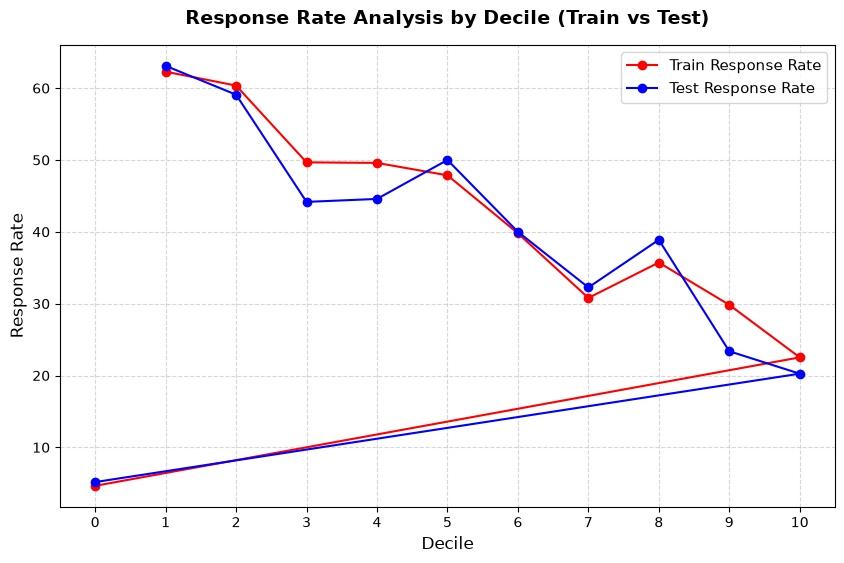

In [29]:
# 2. Plot both lines together
# Passing a list to 'y' plots multiple columns, and 'color' maps to them sequentially
ax = report.plot(
    x='decile_band', 
    y=['response_rate', 'test_response_rate'], 
    kind='line', 
    color=['red', 'blue'],      # response_rate = red, response_rate_test = blue
    marker='o',                 # Adds distinct data points to the lines
    figsize=(10, 6)
)

# 3. Customize titles, labels, and layout
plt.title('Response Rate Analysis by Decile (Train vs Test)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Decile', fontsize=12)
plt.ylabel('Response Rate', fontsize=12)

# Ensure all decile numbers display explicitly on the X-axis
plt.xticks(report['decile_band']) 

# Style the grid lines and legend
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(['Train Response Rate', 'Test Response Rate'], loc='best', fontsize=11)

# 4. Display the chart
plt.show()



# Cleanup

In [30]:
con.close()
os.remove(f"{data}")
